DAY-----------------------------------------------------> 3

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("../Data/online_retail_feature_engineered.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,...,AverageSpend,LifetimeSales,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
3,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
4,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345


In [4]:
rfm = df[[
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary"
]]

rfm = rfm.drop_duplicates()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,13085.0,158,8,2134.08
11,13078.0,3,57,18859.53
29,15362.0,449,2,444.81
50,12682.0,4,50,16406.81
67,18087.0,380,12,1675.26


In [5]:
scaler = StandardScaler()

X = scaler.fit_transform(
    rfm[["Recency","Frequency","Monetary"]]
)

In [6]:
wcss = []

for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(X)

    wcss.append(model.inertia_)

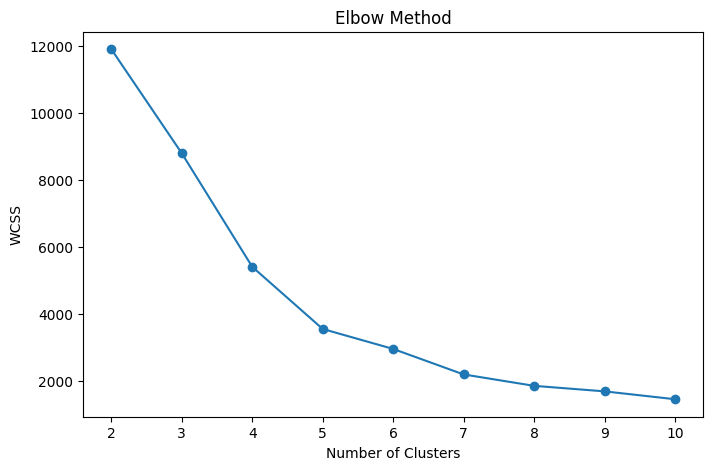

In [7]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(X)

In [9]:
score = silhouette_score(
    X,
    rfm["Cluster"]
)

print("Silhouette Score:", score)

Silhouette Score: 0.5786738021461837


In [10]:
cluster_summary = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,73.605263,5.067251,1231.834383
1,466.366100,2.103613,455.290512
2,1.000000,367.000000,174896.610000
3,26.587912,28.299451,8311.815593
4,49.875000,174.250000,44797.640000


In [11]:
cluster_names = {

    0:"Premium Customers",

    1:"Regular Customers",

    2:"Occasional Customers",

    3:"New Customers",

    4:"High Value Customers"

}

rfm["CustomerSegment"] = (
    rfm["Cluster"]
    .map(cluster_names)
)

In [12]:
rfm["CustomerSegment"].value_counts()

CustomerSegment
Premium Customers       3420
Regular Customers       1882
New Customers            364
High Value Customers       8
Occasional Customers       1
Name: count, dtype: int64

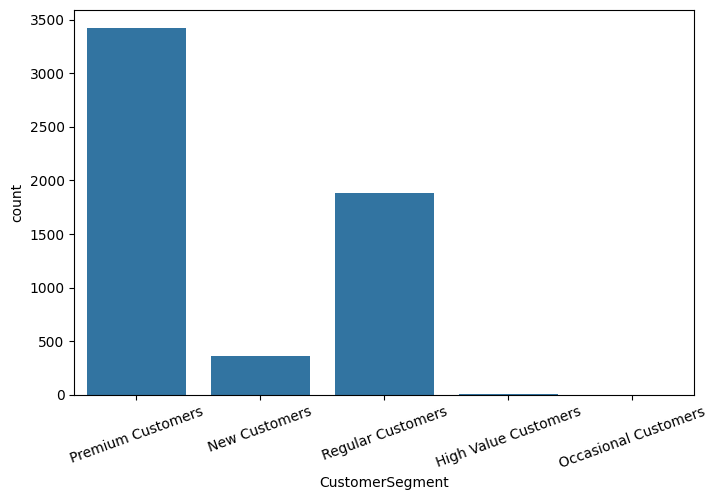

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x="CustomerSegment"
)

plt.xticks(rotation=20)

plt.show()

In [14]:
df = df.merge(

    rfm[["CustomerID","CustomerSegment"]],

    on="CustomerID",

    how="left"

)

In [15]:
df.to_csv(

    "customer_segmented.csv",

    index=False

)

print("Customer Segmentation Completed")

Customer Segmentation Completed


DBSCAN Clustering

In [16]:
dbscan = DBSCAN(

    eps=0.7,

    min_samples=8

)

rfm["DBSCAN_Cluster"] = dbscan.fit_predict(X)

In [17]:
labels = rfm["DBSCAN_Cluster"]

mask = labels != -1

if len(set(labels[mask])) > 1:
    
    score = silhouette_score(
        X[mask],
        labels[mask]
    )

    print("Silhouette Score:", score)

else:

    print("Only one cluster detected.")

Only one cluster detected.


In [18]:
rfm["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 0    5626
-1      49
Name: count, dtype: int64

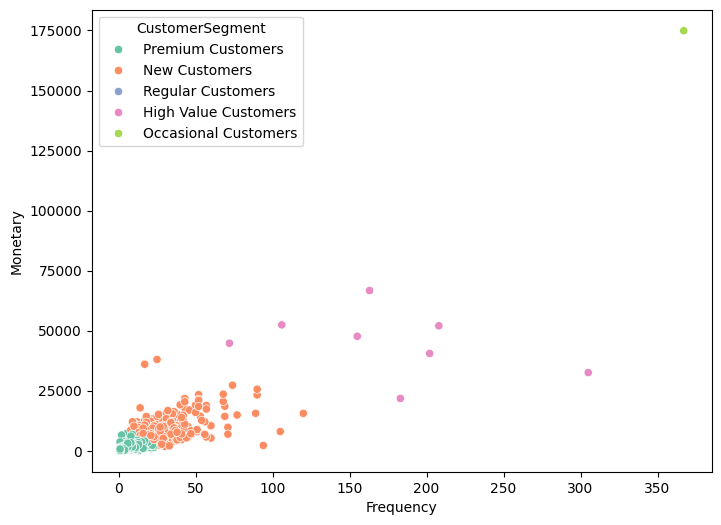

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=rfm,

    x="Frequency",

    y="Monetary",

    hue="CustomerSegment",

    palette="Set2"

)

plt.show()